In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from math import log, sqrt
from mhnlib import utils as mhn_utils
from mhnlib import dynamics as mhn_dynamics
import glasbey
import re
import pandas as pd
import networkx as nx
from sklearn.decomposition import PCA
from scipy.spatial import KDTree
from tqdm.auto import tqdm
import seaborn as sns
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

# Useful functions

In [2]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

def colored_line(
    x,
    y,
    c=None,
    ax=None,
    cmap="viridis",
    norm=None,
    linewidth=2,
    add_colorbar=False,
    colorbar_label=None,
    **kwargs,
):
    """
    Plot a line whose color varies along its length.

    Parameters
    ----------
    x, y : array-like
        Line coordinates.
    c : array-like, optional
        Values controlling the color. Must have len(x).
        Defaults to x.
    ax : matplotlib Axes, optional
        Axes to plot on.
    cmap : str or Colormap
        Matplotlib colormap.
    norm : matplotlib Normalize, optional
        Color normalization.
    linewidth : float
        Line width.
    add_colorbar : bool
        Whether to add a colorbar.
    colorbar_label : str, optional
        Label for the colorbar.
    **kwargs
        Passed to LineCollection.

    Returns
    -------
    lc : LineCollection
    """

    x = np.asarray(x)
    y = np.asarray(y)

    if c is None:
        c = x
    c = np.asarray(c)

    if len(x) != len(y) or len(x) != len(c):
        raise ValueError("x, y, and c must have the same length")

    if ax is None:
        ax = plt.gca()

    points = np.column_stack((x, y))
    segments = np.stack((points[:-1], points[1:]), axis=1)

    if norm is None:
        norm = Normalize(c.min(), c.max())

    # color each segment using the midpoint value
    c_seg = 0.5 * (c[:-1] + c[1:])

    lc = LineCollection(
        segments,
        cmap=cmap,
        norm=norm,
        linewidth=linewidth,
        **kwargs,
    )
    lc.set_array(c_seg)

    ax.add_collection(lc)
    ax.autoscale()

    if add_colorbar:
        cb = ax.figure.colorbar(lc, ax=ax)
        if colorbar_label is not None:
            cb.set_label(colorbar_label)

    return lc

In [3]:
from scipy.cluster.hierarchy import (
    linkage,
    leaves_list,
    optimal_leaf_ordering,
)
from scipy.spatial.distance import pdist, squareform
def hierarchical_haar_from_similarity(S, method="average"):
    S = np.asarray(S)
    N = S.shape[0]

    # similarity -> dissimilarity
    D = S.max() - S
    np.fill_diagonal(D, 0.0)

    d = squareform(D, checks=False)

    Z = linkage(d, method=method)
    Z = optimal_leaf_ordering(Z, d)

    clusters = {i: np.array([i], dtype=int) for i in range(N)}
    wavelets = []

    active = list(range(N))

    # scaling vectors representing the active clusters at each split
    hierarchy = [np.eye(N)]

    for k, row in enumerate(Z):
        a = int(row[0])
        b = int(row[1])

        A = clusters[a]
        B = clusters[b]

        nA = len(A)
        nB = len(B)
        n = nA + nB

        # Haar detail mode
        h = np.zeros(N)
        h[A] = np.sqrt(nB / (nA * n))
        h[B] = -np.sqrt(nA / (nB * n))

        wavelets.append(h)

        # new cluster
        new_node = N + k
        clusters[new_node] = np.concatenate([A, B])

        # update active nodes
        active.remove(a)
        active.remove(b)
        active.append(new_node)

        # scaling vectors for all current clusters
        P = np.zeros((len(active), N))

        for j, node in enumerate(active):
            inds = clusters[node]
            P[j, inds] = 1.0 / len(inds)

        hierarchy.append(P)

    scaling = np.ones(N) / np.sqrt(N)

    H = np.vstack([scaling] + wavelets[::-1])

    return H, Z, clusters, leaves_list(Z), hierarchy
def hierarchical_haar(X, method="average", metric="euclidean"):
    X = np.asarray(X)
    N = X.shape[0]

    distances = pdist(X, metric=metric)

    Z = linkage(distances, method=method)
    Z = optimal_leaf_ordering(Z, distances)

    clusters = {i: np.array([i], dtype=int) for i in range(N)}
    wavelets = []

    # active tree nodes
    active = list(range(N))

    # coarse objects at every hierarchy
    hierarchy = [X.copy()]

    for k, row in enumerate(Z):
        a = int(row[0])
        b = int(row[1])

        A = clusters[a]
        B = clusters[b]

        nA = len(A)
        nB = len(B)
        n = nA + nB

        # Haar detail
        h = np.zeros(N)
        h[A] = np.sqrt(nB / (nA * n))
        h[B] = -np.sqrt(nA / (nB * n))

        wavelets.append(h)

        # new cluster
        new_node = N + k
        clusters[new_node] = np.concatenate([A, B])

        # update active clusters
        active.remove(a)
        active.remove(b)
        active.append(new_node)

        # coarse object for every active cluster
        X_level = np.stack([
            X[clusters[node]].sum(axis=0)
            / len(clusters[node])
            for node in active
        ])

        hierarchy.append(X_level)

    scaling = np.ones(N) / np.sqrt(N)

    # coarse -> fine
    H = np.vstack([scaling] + wavelets[::-1])

    return H, Z, clusters, leaves_list(Z), hierarchy

In [4]:
def disambiguate_fixed_points(x_fp_list, weights, threshold_or_thresholds, complete_linkage):
    if isinstance(threshold_or_thresholds, float):
        thresholds = [threshold_or_thresholds] * len(x_fp_list)
    else:
        thresholds = threshold_or_thresholds
    pbar = tqdm(range(len(x_fp_list)))
    num_fps = [ ]
    x_fps = []
    w_fps = []
    for idx in pbar:
        x_unique, x_unique_counts, labels = mhn_utils.group_by_distance(x_fp_list[idx], float(thresholds[idx]), complete_linkage)
        w_unique = torch.zeros(x_unique.shape[0], weights.shape[-1])
        w_unique.index_add_(0, labels, weights[idx])
        w_unique /= x_unique_counts[:, None]
        num_fps.append(x_unique.shape[0])
        x_fps.append(torch.as_tensor(x_unique))
        w_fps.append(w_unique)
        pbar.set_postfix({"Found clusters" : num_fps[-1] })
    num_fps = torch.as_tensor(num_fps)
    return x_fps, w_fps, num_fps

In [5]:
def fisher_distance(a : torch.Tensor, b : torch.Tensor, w : torch.Tensor):
    diff = a - b
    valid = w > 0

    terms = torch.where(
        valid,
        diff.square() / torch.where(valid, w, 1.0),
        0.0,
    )

    return terms.sum(dim=-1).sqrt()

In [6]:
def get_file_df(root_path, DATASET, FILE_PATTERN):
    all_files = list(root_path.glob(f"{DATASET}{FILE_PATTERN}"))
    file_df = {'is_quenched' : [], 'num_per_label' : [], 'noise' : [], 'is_euclidean' : [], 'is_centered' : [], 'file' : []}
    for file in all_files:
        is_quenched = 'quenched' in file.stem
        num_per_label = re.search(r'per_label=(\d+)', file.stem)
        if num_per_label:
            num_per_label = int(num_per_label.group(1))
        else:
            num_per_label = np.nan
        is_euclidean = 'euclidean=True' in file.stem
        is_centered = 'centered=True' in file.stem
        logit_noise = re.search(r'noise=(\d+\.?\d*)', file.stem)
        if logit_noise:
            logit_noise = float(logit_noise.group(1))
        else:
            logit_noise = None
        file_df['is_quenched'].append(is_quenched)
        file_df['num_per_label'].append(num_per_label)
        file_df['noise'].append(logit_noise)
        file_df['is_euclidean'].append(is_euclidean)
        file_df['is_centered'].append(is_centered)
        file_df['file'].append(str(file.absolute()))
    file_df = pd.DataFrame.from_dict(file_df)
    return file_df

In [7]:
def process_simulation_data(all_x, all_weights, betas, K):
    mean_entropy =mhn_utils.get_entropy(all_weights).mean(dim=-1)
    scaled_mean_entropy = mean_entropy / log(K)
    uniform_idx = torch.argwhere(
        1-scaled_mean_entropy < 1e-4
    ).flatten()
    if len(uniform_idx) == 0:
        start_idx = 0
    else:
        start_idx = uniform_idx[-1].item()
    x_fps, w_fps, num_fps = (
        disambiguate_fixed_points(
            all_x[start_idx:],
            all_weights[start_idx:],
            betas[start_idx:].rsqrt(),
            complete_linkage=False,
        )
    )
    x_fps = (
        list(all_x[:start_idx].mean(dim=1, keepdim=True))
        + x_fps
    )
    w_fps = (
        list(all_weights[:start_idx].mean(dim=1, keepdim=True))
        + w_fps
    )
    num_fps = torch.cat([
        torch.ones(start_idx, dtype=torch.long),
        num_fps,
    ])
    jump_indices = (
        torch.argwhere(
            torch.diff(num_fps) > 0
        ).flatten()
        + 1
    )
    jump_indices = torch.cat([
        torch.zeros(1, dtype=jump_indices.dtype),
        jump_indices,
    ])

    if jump_indices[-1] != len(num_fps) - 1:
        jump_indices = torch.cat([
            jump_indices,
            torch.as_tensor([len(num_fps) - 1], dtype=jump_indices.dtype),
        ])

    edgelist_from = []
    edgelist_to = []
    edge_weights = []
    # --------------------------------------------------
    # Match every FP to its closest FP at previous beta
    # --------------------------------------------------
    for beta_idx in range(1, len(betas)):
        w_fp = w_fps[beta_idx]
        w_fp_prev = w_fps[beta_idx - 1]
        dist = fisher_distance(
            w_fp[:, None, :],
            w_fp_prev[None, :, :],
            w_fp_prev[None, :, :],
        )
        closest_prev_idx = dist.argmin(dim=1)
        for idx in range(len(w_fp)):
            parent_idx = closest_prev_idx[idx].item()
            # old -> new
            edgelist_from.append(
                (beta_idx - 1, parent_idx)
            )
            edgelist_to.append(
                (beta_idx, idx)
            )
            edge_weights.append(
                dist[idx, parent_idx].item()
            )
    # --------------------------------------------------
    # Nodes
    # --------------------------------------------------
    fp_nodes = []
    for beta_idx in range(len(w_fps)):
        for idx in range(len(w_fps[beta_idx])):
            fp_nodes.append((beta_idx, idx))
    # --------------------------------------------------
    # DAG
    # --------------------------------------------------
    G = nx.DiGraph()
    G.add_nodes_from(fp_nodes)
    G.add_weighted_edges_from(
        zip(
            edgelist_from,
            edgelist_to,
            edge_weights,
        )
    )
    branching_nodes = [
    node for node in G.nodes
    if G.out_degree(node) > 1
    ]
    branching_indices = [0] + [
        node[0] for node in branching_nodes]
    if branching_indices[-1] != len(betas) - 1:
        branching_indices.append(len(betas) - 1)
    branching_indices = torch.as_tensor(branching_indices)
    return x_fps, w_fps, num_fps, jump_indices, G, fp_nodes, branching_nodes, branching_indices

In [8]:
def pcdp(X, num_iterations):
    def cluster_stats(indices):
        n = len(indices)

        if n == 0:
            return None, None, None, None

        Xc = X[indices]

        if n == 1:
            mean = Xc[0]
            val_max = X.new_tensor(0.0)
            vec_max = torch.zeros(
                X.shape[1],
                device=X.device,
                dtype=X.dtype,
            )
            return mean, val_max, vec_max, indices

        mean = Xc.mean(dim=0)

        _, s, vh = torch.linalg.svd(
            Xc - mean,
            full_matrices=False,
        )

        val_max = s[0]**2 / n
        vec_max = vh[0]

        return mean, val_max, vec_max, indices

    clustering = {}

    # Root
    indices = torch.arange(X.shape[0], device=X.device)
    clustering[0] = {
        0: cluster_stats(indices)
    }

    # Recursive binary splitting
    for iteration in range(1, num_iterations):
        clustering[iteration] = {}

        for cluster_id, (mean, val, vec, indices) in clustering[iteration - 1].items():

            if indices is None or len(indices) <= 1:
                continue

            projection = (X[indices] - mean) @ vec

            left_indices = indices[projection > 0]
            right_indices = indices[projection <= 0]

            clustering[iteration][2 * cluster_id] = cluster_stats(left_indices)
            clustering[iteration][2 * cluster_id + 1] = cluster_stats(right_indices)

    return clustering

In [9]:
def simplex_to_polygon(w):
    # w: (..., K), sum over K = 1
    K = w.shape[-1]
    theta = 2 * torch.pi * torch.arange(K) / K
    vertices = torch.stack([torch.cos(theta), torch.sin(theta)], dim=-1)  # (K, 2)
    return w @ vertices

In [10]:
def pcdp_elaborate(X, num_iterations):
    clustering = pcdp(X, num_iterations)
    nodes = [ (level, index)    for level in clustering.keys() for index in clustering[level].keys()]
    centroids = []
    beta_effective = []
    edgelist_from = []
    edgelist_to = []
    for node in nodes:
        level, index = node
        if level + 1 in clustering:
            if 2 * index in clustering[level + 1]:
                edgelist_from.append(node)
                edgelist_to.append((level + 1, 2 * index))
            if 2 * index + 1 in clustering[level + 1]:
                edgelist_from.append(node)
                edgelist_to.append((level + 1, 2 * index + 1))
    edgelist_from = torch.as_tensor(edgelist_from, dtype=torch.long)
    edgelist_to = torch.as_tensor(edgelist_to, dtype=torch.long)
    for node in nodes:
        level, index = node
        mean, val, vec, indices = clustering[level][index]
        if mean is None:
            centroids.append(torch.empty(X.shape[1], device=X.device))
            beta_effective.append(torch.tensor(np.nan, device=X.device))
        else:
            centroids.append(mean)
            beta_effective.append(1.0/val)
    centroids = torch.stack(centroids, dim=0)
    beta_effective = torch.stack(beta_effective, dim=0)
    return centroids, beta_effective, edgelist_from, edgelist_to

# Select dataset

In [65]:
DATASET = "mnist"
IS_IMAGE = DATASET in ["mnist", "stl10", "cifar10", "cifar100"]
num_per_label = 5  if IS_IMAGE else None

In [66]:
source_data_path = Path("paper_results/data/")
source_data_file = source_data_path / (f"{DATASET}_per_label={num_per_label}.pt" if IS_IMAGE else f"{DATASET}.pt")
source_data_dict = torch.load(source_data_file)
data = source_data_dict['data']
latents = source_data_dict.get('latents', None)
labels = source_data_dict['labels']
label_to_name = source_data_dict.get('label_to_name', None)
unique_labels = torch.unique(labels)
unique_labels_palette = mcolors.to_rgba_array(glasbey.create_palette(len(unique_labels)))
colors = []
for label in labels:
    label_idx = torch.where(unique_labels == label)[0].item()
    colors.append(unique_labels_palette[label_idx])
colors = np.array(colors)
K = data.shape[0]

# Single experiment analysis

In [ ]:
experiment_name = "data_quenched"
root_path = Path(f"paper_results/experiments/{experiment_name}/")

file_df = get_file_df(root_path, DATASET, FILE_PATTERN="*weights_quenched*.pt")

plots_path = Path(f"paper_results/plots/{experiment_name}/{DATASET}/")
plots_path.mkdir(parents=True, exist_ok=True)

plots_sequences_path = Path(f"paper_results/plots/{experiment_name}/{DATASET}/sequences/")
plots_sequences_path.mkdir(parents=True, exist_ok=True)

## Load

In [ ]:
is_centered = True
is_euclidean = False
is_quenched = True
logit_noise = None
file_mask = (file_df['is_euclidean'] == is_euclidean) & (file_df['is_centered'] == is_centered) & (file_df['is_quenched'] == is_quenched)
if num_per_label is not None:
    file_mask = file_mask & (file_df['num_per_label'] == num_per_label)
    if logit_noise is not None:
        file_mask = file_mask & (file_df['noise'] == logit_noise)
    else:
        file_mask = file_mask & pd.isna(file_df['noise'])
else:
    file_mask = file_mask & pd.isna(file_df['noise'])
    if logit_noise is not None:
        file_mask = file_mask & (file_df['noise'] == logit_noise)
    else:
        file_mask = file_mask & pd.isna(file_df['noise'])
if file_mask.sum() == 0:
    raise ValueError("No files found matching the specified criteria.")
elif file_mask.sum() > 1:
    raise ValueError("Multiple files found matching the specified criteria.")
file_name = file_df[file_mask]['file'].iloc[0]

save_file_structure = f"{DATASET}"
if num_per_label is not None:
    save_file_structure += f"_per_label={num_per_label}"
save_file_structure += f"_quenched={is_quenched}_centered={is_centered}_euclidean={is_euclidean}"

In [ ]:
data_dict = torch.load(file_name)
all_weights = data_dict['weights']
shift = data_dict['shift']
rms = data_dict['rms']
betas = data_dict['betas']
biases = data_dict['biases']
patterns = data_dict['patterns']
K = patterns.shape[0]
gram = patterns @ patterns.T
patterns_cov = torch.cov(patterns.T)
all_x = all_weights @ patterns
beta_c = 1.0/torch.linalg.eigvalsh(mhn_utils.get_dual_symmetric_stability_matrix(gram, torch.ones(K)/K))[-1].item()
beta_sigma = 1.0/torch.var(patterns, dim=0).sum().item()
#beta_max = 1.0/torch.norm(patterns, dim=1).max().item()
beta_nn = 1.0/KDTree(patterns.cpu().numpy()).query(patterns.cpu().numpy(), k=2)[0][:,1].mean()**2

In [ ]:
fig, ax = plt.subplots(figsize=(len(unique_labels), 1))
for label_idx, label in enumerate(unique_labels):
    ax.scatter(label_idx, 0, color=unique_labels_palette[label_idx], s=1000)
ax.set_xticks(range(len(unique_labels)))
if label_to_name is not None and label_to_name != {}:
    ax.set_xticklabels([label_to_name[label.item()] for label in unique_labels], rotation=90)
else:
    ax.set_xticklabels([str(label.item()) for label in unique_labels], rotation=90)
ax.yaxis.set_visible(False)
if IS_IMAGE:
    plt.savefig(plots_path /  (f"{DATASET}_per_label={num_per_label}_labels_palette.pdf"), bbox_inches='tight', dpi=300)
else:
    plt.savefig(plots_path /  (f"{DATASET}_labels_palette.pdf"), bbox_inches='tight', dpi=300)
plt.show()

## Derived quantities

In [ ]:
x_fps, w_fps, num_fps, jump_indices, G, fp_nodes, branching_nodes, branching_indices = process_simulation_data(all_x, all_weights, betas, K)

In [ ]:
if IS_IMAGE:
    from diffusers import AutoencoderKL
    ae_model = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse")
    ae_model = ae_model.to(device).eval()
    ae_model.requires_grad_(False)
    ae_scaling = ae_model.config.scaling_factor

    C_latents, H_latents, W_latents = latents.shape[1:]

    image_fps = []
    for x in x_fps:
        torch.cuda.empty_cache()
        images = ae_model.decode((x*rms + shift).view(-1,C_latents, H_latents, W_latents).to(device)).sample.cpu()
        image_fps.append(images)

    #image_annealed_fps = []
    #for x in x_annealed_fps:
    #    torch.cuda.empty_cache()
    #    images = ae_model.decode(x.view(-1,C_latents, H_latents, W_latents).to(device)).sample.cpu()
    #    image_annealed_fps.append(images)
else:
    image_fps = None
    #image_annealed_fps = None

## Plots

### Subspace similarities

In [ ]:
H, Z, clusters, order, hierarchy = hierarchical_haar(patterns)
H = torch.as_tensor(H, dtype=torch.float32)

In [ ]:
def orth_basis(X, rtol=1e-10):
    """
    X: (p, d), vectors stored as rows.
    Returns Q: (d, rank), orthonormal basis of their span.
    """
    U, s, _ = np.linalg.svd(X.T, full_matrices=False)

    if len(s) == 0:
        return U[:, :0]

    rank = np.sum(s > rtol * s[0])

    return U[:, :rank]


def get_similarities(x_coll_1, x_coll_2):
    similarities = np.zeros((len(x_coll_1), len(x_coll_2)))

    for counter_1, x_1 in enumerate(x_coll_1):
        Q_1 = orth_basis(np.asarray(x_1))

        for counter_2, x_2 in enumerate(x_coll_2):
            Q_2 = orth_basis(np.asarray(x_2))

            overlap = np.linalg.norm(Q_1.T @ Q_2, "fro")**2

            similarity = overlap / np.sqrt(
                Q_1.shape[1] * Q_2.shape[1]
            )

            similarities[counter_1, counter_2] = similarity

    return similarities

In [ ]:
x_fps_jump = [x_fps[idx] for idx in jump_indices]
sim_hn_hier = get_similarities(x_fps_jump, hierarchy[::-1])
pca_model = PCA(n_components=min(patterns.shape[0], patterns.shape[1])).fit(patterns.cpu().numpy())
pca_bases = [ pca_model.components_[:idx]  for idx in range(1, len(hierarchy)+1)]

sim_hn_pca = get_similarities(x_fps_jump, pca_bases)
from sklearn.cluster import KMeans
kmeans_bases = [ KMeans(n_clusters=idx, random_state=1101252).fit(patterns.cpu().numpy()).cluster_centers_ for idx in range(1, len(hierarchy)+1)]

sim_hn_kmeans = get_similarities(x_fps_jump, kmeans_bases)

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
im0 = axs[0].imshow(sim_hn_hier, aspect='equal', cmap='coolwarm', vmin=0, vmax=1)
axs[0].set_title("Hierarchical Haar")
plt.colorbar(im0, ax=axs[0], shrink=0.8)
im1 = axs[1].imshow(sim_hn_pca, aspect='equal', cmap='coolwarm', vmin=0, vmax=1)
axs[1].set_title("PCA")
plt.colorbar(im1, ax=axs[1], shrink=0.8)
im2 = axs[2].imshow(sim_hn_kmeans, aspect='equal', cmap='coolwarm', vmin=0, vmax=1)
axs[2].set_title("KMeans")
plt.colorbar(im2, ax=axs[2], shrink=0.8)
plt.savefig(plots_path /  (save_file_structure + f"_recon_basis.pdf"), bbox_inches='tight', dpi=300)
plt.close()

In [ ]:
#num_cols = 10
#num_rows = int(np.ceil(len(hierarchy)/num_cols))
#fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols*4, num_rows*4))
#if num_rows == 1:
#    axs = axs[None,...]
#for reverse_hierarchy_level in range(len(hierarchy)):
#    hierarchy_level = len(hierarchy) - 1 - reverse_hierarchy_level
#    row_idx = hierarchy_level // num_cols
#    col_idx = hierarchy_level % num_cols
#    x_hl = torch.as_tensor(hierarchy[hierarchy_level], dtype=torch.float32)
#    x_hl_propagated = mhn_utils.deterministic_dynamics(patterns.to('cuda'), biases.to('cuda'), betas.to('cuda'), x_hl.to('cuda'), num_iterations=1000).cpu().squeeze(1)
#    distances = torch.norm(x_hl_propagated - x_hl[None,...], dim=-1)
#    axs[row_idx, col_idx].imshow(distances.clamp(min=1e-5).log10(), aspect='auto', cmap='seismic', vmin=-5, vmax=0)
#    axs[row_idx, col_idx].set_xticks(np.arange(0, distances.shape[1], 1))
#plt.show()

In [ ]:
num_cols = 10
num_rows = int(np.ceil(len(hierarchy)/num_cols))
fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols*4, num_rows*4))
if num_rows == 1:
    axs = axs[None,...]
for hierarchy_level in range(len(hierarchy)-1, -1, -1):
    plot_idx = len(hierarchy) - 1 - hierarchy_level
    row_idx = plot_idx // num_cols
    col_idx = plot_idx % num_cols
    x_hl = torch.as_tensor(hierarchy[hierarchy_level], dtype=torch.float32)
    A =  patterns @ torch.linalg.pinv(x_hl)
    patterns_fitted = A @ x_hl
    axs[row_idx, col_idx].imshow(patterns_fitted @ patterns_fitted.T, aspect='equal', cmap='coolwarm', vmin=gram.min().item(), vmax=gram.max().item())
    axs[row_idx, col_idx].set_title(f"Nc: {x_hl.shape[0]}")
    axs[row_idx, col_idx].xaxis.set_visible(False)
    axs[row_idx, col_idx].yaxis.set_visible(False)
plt.savefig(plots_path /  (save_file_structure + f"_hierarchical_haar_effective_gram.pdf"), bbox_inches='tight', dpi=300)
plt.close()


fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols*4, num_rows*4))
if num_rows == 1:
    axs = axs[None,...]
for hierarchy_level in range(len(hierarchy)-1, -1, -1):
    plot_idx = len(hierarchy) - 1 - hierarchy_level
    row_idx = plot_idx // num_cols
    col_idx = plot_idx % num_cols
    x_hl = torch.as_tensor(hierarchy[hierarchy_level], dtype=torch.float32)
    axs[row_idx, col_idx].imshow(torch.cov(x_hl.T), aspect='equal', cmap='coolwarm', vmin=patterns_cov.min().item(), vmax=patterns_cov.max().item())
    axs[row_idx, col_idx].set_title(f"Nc: {x_hl.shape[0]}")
    axs[row_idx, col_idx].xaxis.set_visible(False)
    axs[row_idx, col_idx].yaxis.set_visible(False)
plt.savefig(plots_path /  (save_file_structure + f"_hierarchical_haar_covariance.pdf"), bbox_inches='tight', dpi=300)
plt.close()

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(gram, aspect='equal', cmap='coolwarm', vmin=gram.min().item(), vmax=gram.max().item())
ax.yaxis.set_visible(False)
ax.xaxis.set_visible(False)
plt.savefig(plots_path /  (save_file_structure + f"_gram.pdf"), bbox_inches='tight', dpi=300)
plt.close()
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(patterns_cov, aspect='equal', cmap='coolwarm', vmin=patterns_cov.min().item(), vmax=patterns_cov.max().item())
ax.yaxis.set_visible(False)
ax.xaxis.set_visible(False)
plt.savefig(plots_path /  (save_file_structure + f"_covariance.pdf"), bbox_inches='tight', dpi=300)
plt.close()
num_cols = 10
num_rows = int(np.ceil(len(jump_indices)/num_cols))
fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols*4, num_rows*4))
if num_rows == 1:
    axs = axs[None,...]
for idx, beta_idx in enumerate(jump_indices):
    row_idx = idx // num_cols
    col_idx = idx % num_cols
    A =  patterns @ torch.linalg.pinv(x_fps[beta_idx])
    patterns_fitted = A @ x_fps[beta_idx]
    axs[row_idx, col_idx].imshow(patterns_fitted @ patterns_fitted.T, aspect='equal', cmap='coolwarm', vmin=gram.min().item(), vmax=gram.max().item())
    axs[row_idx, col_idx].set_title(f"Nfp: {x_fps[beta_idx].shape[0]}")
    axs[row_idx, col_idx].xaxis.set_visible(False)
    axs[row_idx, col_idx].yaxis.set_visible(False)
plt.savefig(plots_path /  (save_file_structure + f"_fixed_points_effective_gram.pdf"), bbox_inches='tight', dpi=300)
plt.close()


fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols*4, num_rows*4))
if num_rows == 1:
    axs = axs[None,...]
for idx, beta_idx in enumerate(jump_indices):
    row_idx = idx // num_cols
    col_idx = idx % num_cols
    axs[row_idx, col_idx].imshow(torch.cov(x_fps[beta_idx].T), aspect='equal', cmap='coolwarm', vmin=patterns_cov.min().item(), vmax=patterns_cov.max().item())
    axs[row_idx, col_idx].set_title(f"Nfp: {x_fps[beta_idx].shape[0]}")
    axs[row_idx, col_idx].xaxis.set_visible(False)
    axs[row_idx, col_idx].yaxis.set_visible(False)
plt.savefig(plots_path /  (save_file_structure + f"_fixed_points_effective_covariance.pdf"), bbox_inches='tight', dpi=300)
plt.close()

### Entropy

In [ ]:
mean_entropy = mhn_utils.get_entropy(all_weights).mean(dim=-1)
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(betas, mean_entropy/log(K))
ax.scatter(
    betas[jump_indices],
    mean_entropy[jump_indices]/log(K),
    color='r',
    marker='x',
    label="Jumps in $N_{FP}$",
)
#ax.scatter(
#    betas[branching_indices],
#    mean_entropy[branching_indices]/log(K),
#    color='b',
#    marker='x',
#    label="Branching points",
#)
ax.axvline(beta_c, color='k', linestyle='--', label=f"$\\beta_c={beta_c:.2f}$", linewidth=2.0)
ax.axvline(beta_nn, color='red', linestyle='--', label="$\\beta_{nn}=$" + f"{beta_nn:.2f}", linewidth=2.0)
#ax.axvline(beta_max, color='blue', linestyle='--', label="$\\beta_{max}=$" + f"{beta_max:.2f}", linewidth=2.0)
ax.axvline(beta_sigma, color='green', linestyle='--', label="$\\beta_\\sigma=$" + f"{beta_sigma:.2f}", linewidth=2.0)
plt.xscale('log')
ax.set_xlabel("$\\beta$")
ax.set_ylabel("$H/\\log(K)$")
plt.legend()
plt.savefig(plots_path / f"{save_file_structure}_entropy.pdf", dpi=300, bbox_inches='tight')
plt.show()

### PCA plots

In [ ]:
pca_model = PCA(n_components=5).fit(patterns)
patterns_proj = pca_model.transform(patterns)
grayscale_conversion = torch.tensor([0.299, 0.587, 0.114])
for beta_idx in jump_indices:
    x_fp = x_fps[beta_idx]
    x_fp_proj = torch.as_tensor(pca_model.transform(x_fp))
    closest_fp_idx = ((patterns[:,None,:] - x_fp[None,:,:])**2).sum(dim=-1).argmin(dim=1)
    fig, axs = plt.subplots(ncols=2, figsize=(8,3))
    axs[0].scatter(patterns_proj[:,0], patterns_proj[:,1], s= 70, color=colors)
    axs[0].scatter(x_fp_proj[:,0], x_fp_proj[:,1], color='gray',  marker='s', s=50, edgecolors='black')
    for idx in range(len(x_fp)):
        axs[0].text(x_fp_proj[idx,0], x_fp_proj[idx,1], f"({beta_idx},{idx})", fontsize=8, color='black', ha='center', va='top')
    axs[0].set_xlabel("PCA #1")
    axs[0].set_ylabel("PCA #2")
    axs[1].scatter(patterns_proj[:,2], patterns_proj[:,3], s = 70, color=colors)
    axs[1].scatter(x_fp_proj[:,2], x_fp_proj[:,3], color='gray',  marker='s', s=50, edgecolors='black')
    for idx in range(len(x_fp)):
        axs[1].text(x_fp_proj[idx,2], x_fp_proj[idx,3], f"({beta_idx},{idx})", fontsize=8, color='black', ha='center', va='top')
    axs[1].set_xlabel("PCA #3")
    axs[1].set_ylabel("PCA #4")
    axs[0].set_aspect('equal')
    axs[1].set_aspect('equal')
    plt.savefig(plots_sequences_path /  (save_file_structure + f"_beta_idx={beta_idx}_pca_fp.pdf"), bbox_inches='tight', dpi=300)
    plt.close()
    if IS_IMAGE:
        fig, axs = plt.subplots(ncols=image_fps[beta_idx].shape[0], figsize=(4*image_fps[beta_idx].shape[0],4))
        if image_fps[beta_idx].shape[0] == 1:
            axs = [axs]
        for idx in range(image_fps[beta_idx].shape[0]):
            image = (1+image_fps[beta_idx][idx].permute(1,2,0).clip(-1,1))/2
            
            if DATASET == "mnist":
                axs[idx].imshow(image @ grayscale_conversion, vmin=0, vmax=1, cmap='gray')
            else:
                axs[idx].imshow(image)
            axs[idx].set_title(f"({beta_idx},{idx})")    
        plt.savefig(plots_sequences_path /  (save_file_structure + f"_beta_idx={beta_idx}_image_fp.pdf"), bbox_inches='tight', dpi=300)
        plt.close()

# Cont. Annealing

In [ ]:
def run_annealing(patterns,biases, 
                  noise_ic_factor,
                  beta_ic_factor, 
                  beta_final_factor, beta_logspace, num_ics_per_pattern, num_iterations_per_beta, num_betas, batch_size, device):
    K = patterns.shape[0]
    
    
    stab_matr = mhn_utils.get_dual_symmetric_stability_matrix(gram, torch.ones(K)/K)
    beta_c = 1.0/torch.linalg.eigvalsh(stab_matr).max().item()
    beta_ic = beta_ic_factor * beta_c
    beta_final = beta_final_factor * beta_c
    noise_ic_std = noise_ic_factor / sqrt(beta_c)
    x_init = patterns.expand(num_ics_per_pattern, K, -1) + torch.randn(num_ics_per_pattern, K, patterns.shape[-1])*noise_ic_std
    x_init = x_init.view(-1, patterns.shape[-1])
    w_noisy_ic = torch.softmax( (x_init @ patterns.T + biases)*beta_ic, dim=-1)
    torch.manual_seed(1101252)
    w_annealed = []
    for batch_start in tqdm(range(0, num_ics_per_pattern*K, batch_size)):
        torch.cuda.empty_cache()
        batch_end = min(batch_start + batch_size, num_ics_per_pattern*K)
        w_annealed_batch, betas = mhn_utils.dual_deterministic_dynamics_cont_annealing(gram.to(device),
                                                                              biases.to(device),
                                                                              w_noisy_ic[batch_start:batch_end].to(device),
                                                                              beta_ic,
                                                                              beta_final,
                                                                              beta_logspace=beta_logspace,
                                                                              num_betas=num_betas,
                                                                              num_iterations_per_beta=num_iterations_per_beta,
                                                                                verbose=False,
                                                                                dt = None)
        w_annealed_batch = w_annealed_batch.cpu().squeeze()
        w_annealed.append(w_annealed_batch)
    w_annealed = torch.cat(w_annealed, dim=1)
    betas = betas.cpu().squeeze()
    return w_annealed, beta_ic, beta_final, betas

In [ ]:
is_centered = False
is_euclidean = True
raw_patterns = torch.clone(data.view(data.shape[0],-1)) if latents is None else torch.clone(latents.view(latents.shape[0],-1))
if is_centered or is_euclidean:
    shift, rms, patterns = mhn_utils.shift_and_rms(raw_patterns)
else:
    shift = torch.zeros(raw_patterns.shape[-1])
    rms = raw_patterns.norm(dim=1).square().mean().sqrt()
    rms = rms.clamp_min(1e-12)
    patterns = raw_patterns / rms
K = patterns.shape[0]
gram = patterns @ patterns.T
if is_euclidean:
    biases = -0.5*torch.diagonal(gram)
else:
    biases = torch.zeros(K)

In [ ]:
w_annealed, beta_ic, beta_final, betas = run_annealing(patterns,
                            biases, 
                            noise_ic_factor=1.0,
                            beta_ic_factor=1.0, 
                            beta_final_factor=10.0, 
                            beta_logspace = False,
                            num_ics_per_pattern=100, num_iterations_per_beta=100, num_betas=2000, batch_size=1000, device=device)

In [ ]:
x_annealed =  torch.einsum("...k,ki->...i", w_annealed, patterns)

In [ ]:
x_annealed_beta_distances = torch.diff(x_annealed, dim=0).norm(dim=-1)

In [ ]:
pca_model = PCA(n_components=5).fit(patterns)
patterns_proj = pca_model.transform(patterns)
x_annealed_proj = torch.as_tensor(pca_model.transform(x_annealed.view(-1, patterns.shape[-1]))).view(x_annealed.shape[0], x_annealed.shape[1], -1)

In [ ]:
plt.scatter(patterns_proj[:,0], patterns_proj[:,1], s= 70, color=colors)
for ic_idx in range(x_annealed_proj.shape[1]):
    plt.plot(x_annealed_proj[:,ic_idx,0], x_annealed_proj[:,ic_idx,1], color='gray', alpha=0.5)

# Test data

In [ ]:
experiment_name = "test_data_quenched"
root_path = Path(f"paper_results/experiments/{experiment_name}/")

#file_df = get_file_df(root_path, DATASET, FILE_PATTERN="*weights_quenched*.pt")

plots_path = Path(f"paper_results/plots/{experiment_name}/{DATASET}/")
plots_path.mkdir(parents=True, exist_ok=True)

plots_sequences_path = Path(f"paper_results/plots/{experiment_name}/{DATASET}/sequences/")
plots_sequences_path.mkdir(parents=True, exist_ok=True)

In [ ]:
test_data_file = source_data_path / f"{DATASET}_test.pt"
test_data_dict = torch.load(test_data_file)
test_data = test_data_dict['data']
test_latents = test_data_dict.get('latents', None)
test_labels = test_data_dict['labels']
test_sorting_idx = torch.argsort(test_labels)
test_data = test_data[test_sorting_idx]
test_labels = test_labels[test_sorting_idx]
test_colors = []
for label in test_labels:
    label_idx = torch.where(unique_labels == label)[0].item()
    test_colors.append(unique_labels_palette[label_idx])
test_colors = np.array(test_colors)

In [ ]:
is_centered = False
is_euclidean = True
raw_patterns = torch.clone(data.view(data.shape[0],-1)) if latents is None else torch.clone(latents.view(latents.shape[0],-1))
if is_centered or is_euclidean:
    shift, rms, patterns = mhn_utils.shift_and_rms(raw_patterns)
else:
    shift = torch.zeros(raw_patterns.shape[-1])
    rms = raw_patterns.norm(dim=1).square().mean().sqrt()
    rms = rms.clamp_min(1e-12)
    patterns = raw_patterns / rms
K = patterns.shape[0]
gram = patterns @ patterns.T
if is_euclidean:
    biases = -0.5*torch.diagonal(gram)
else:
    biases = torch.zeros(K)

In [ ]:
test_raw_patterns = torch.clone(test_data.view(test_data.shape[0],-1)) if test_latents is None else torch.clone(test_latents.view(test_latents.shape[0],-1))
test_patterns = test_raw_patterns - shift
test_patterns /= rms

### Corruption test

In [ ]:
corruption_levels = [0.1, 0.5, 1.0, 2.0, 5.0]
for corruption_level in corruption_levels:
    test_patterns_corrupted = test_patterns + torch.randn_like(test_patterns) * corruption_level
    

In [ ]:
centroids_div, beta_effective_div, edgelist_from_div, edgelist_to_div = pcdp_elaborate(patterns, num_iterations=10)

In [ ]:
betas = torch.logspace(1, 2, 31)
all_x, all_weights = mhn_utils.deterministic_dynamics(patterns.to(device), 
                                 biases.to(device), betas.to(device), test_patterns.to(device), num_iterations=1000, verbose=True, dt=None, return_probs=True)
all_x = all_x.squeeze(1).cpu()
all_weights = all_weights.squeeze(1).cpu()

In [ ]:
pca_model = PCA(n_components=5).fit(patterns)
patterns_proj = pca_model.transform(patterns)
all_x_proj = torch.as_tensor(pca_model.transform(all_x.view(-1, patterns.shape[-1]))).view(all_x.shape[0], all_x.shape[1], -1)

In [ ]:
mean_entropy =mhn_utils.get_entropy(all_weights).mean(dim=-1)
scaled_mean_entropy = mean_entropy / log(K)
uniform_idx = torch.argwhere(
    1-scaled_mean_entropy < 1e-4
).flatten()
if len(uniform_idx) == 0:
    start_idx = 0
else:
    start_idx = uniform_idx[-1].item()
x_fps, w_fps, num_fps = (
    disambiguate_fixed_points(
        all_x[start_idx:],
        all_weights[start_idx:],
        betas[start_idx:].rsqrt(),
        complete_linkage=False,
    )
)
x_fps = (
    list(all_x[:start_idx].mean(dim=1, keepdim=True))
    + x_fps
)
w_fps = (
    list(all_weights[:start_idx].mean(dim=1, keepdim=True))
    + w_fps
)
num_fps = torch.cat([
    torch.ones(start_idx, dtype=torch.long),
    num_fps,
])
jump_indices = (
    torch.argwhere(
        torch.diff(num_fps) > 0
    ).flatten()
    + 1
)
jump_indices = torch.cat([
    torch.zeros(1, dtype=jump_indices.dtype),
    jump_indices,
    torch.tensor([len(num_fps) - 1], dtype=jump_indices.dtype)
])
if jump_indices[-1] == jump_indices[-2]:
    jump_indices = jump_indices[:-1]

In [ ]:
if IS_IMAGE:
    from diffusers import AutoencoderKL
    ae_model = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse")
    ae_model = ae_model.to(device).eval()
    ae_model.requires_grad_(False)
    ae_scaling = ae_model.config.scaling_factor

    C_latents, H_latents, W_latents = latents.shape[1:]

    image_fps = []
    for x in tqdm(x_fps):
        torch.cuda.empty_cache()
        images = ae_model.decode((x*rms + shift).view(-1,C_latents, H_latents, W_latents).to(device)).sample.cpu()
        image_fps.append(images)
    torch.cuda.empty_cache()
else:
    image_fps = None

In [ ]:
base_cov = torch.cov(patterns.T)
base_mean = patterns.mean(dim=0)
val_max, vec_max = torch.linalg.eigh(base_cov)
val_max = val_max[-1].item()
vec_max = vec_max[:,-1].cpu()
clustering = [(base_mean, val_max, vec_max,torch.arange(K))]
for split_order in range(10):
    cluster_variances = torch.tensor([val_max for _, val_max, _, _ in clustering])
    largest_cluster_idx = cluster_variances.argmax().item()
    mean, val, vec, indices = clustering[largest_cluster_idx]
    
    cluster_patterns = patterns[indices]
    projections = (cluster_patterns - mean) @ vec_max
    pos_indices = indices[torch.argwhere(projections > 0).flatten()]
    neg_indices = indices[torch.argwhere(projections <= 0).flatten()]
    if len(pos_indices) > 1:
        pos_cov = torch.cov(patterns[pos_indices].T)
        pos_val_max, pos_vec_max = torch.linalg.eigh(pos_cov)
        pos_val_max = pos_val_max[-1].item()
        pos_vec_max = pos_vec_max[:,-1].cpu()

    if len(neg_indices) > 1:
        neg_cov = torch.cov(patterns[neg_indices].T)
        neg_val_max, neg_vec_max = torch.linalg.eigh(neg_cov)
        neg_val_max = neg_val_max[-1].item()
        neg_vec_max = neg_vec_max[:,-1].cpu()

    if len(pos_indices) <= 1 or len(neg_indices) <= 1:
        continue
    clustering.pop(largest_cluster_idx)
    clustering.append((patterns[neg_indices].mean(dim=0), neg_val_max, neg_vec_max, neg_indices))
    clustering.append((patterns[pos_indices].mean(dim=0), pos_val_max, pos_vec_max, pos_indices))

In [ ]:
clusters = torch.stack([mean for mean, val, vec, indices in clustering])
cluster_variances = torch.tensor([val for mean, val, vec, indices in clustering])
clusters_proj = torch.as_tensor(pca_model.transform(clusters))
plt.scatter(patterns_proj[:,0], patterns_proj[:,1], s= 70, color='gray', alpha=0.5)
plt.scatter(clusters_proj[:,0], clusters_proj[:,1], s= 70, c=cluster_variances, cmap='viridis', edgecolors='black')

In [ ]:
base_cov = torch.cov(patterns.T)
base_mean = patterns.mean(dim=0)
val_max, vec_max = torch.linalg.eigh(base_cov)
val_max = val_max[-1].item()
vec_max = vec_max[:,-1].cpu()
split_dict = {}
split_dict[(0,0)] = (base_mean, val_max, vec_max, torch.ones(K, dtype=bool))
for split_order in range(5):
    valid_keys = list(filter(lambda k: k[0] == split_order, split_dict.keys()))
    next_split_index = 0
    for key in valid_keys:
        mean, val, vec, mask = split_dict[key]
        raw_mask = (patterns - mean) @ vec > 0
        pos_mask = raw_mask & mask
        neg_mask = (~raw_mask) & mask
        pos_cov = torch.cov(patterns[pos_mask].T)
        pos_mean = patterns[pos_mask].mean(dim=0)
        pos_val_max, pos_vec_max = torch.linalg.eigh(pos_cov)
        pos_val_max = pos_val_max[-1].item()
        pos_vec_max = pos_vec_max[:,-1].cpu()
        neg_cov = torch.cov(patterns[neg_mask].T)
        neg_mean = patterns[neg_mask].mean(dim=0)
        neg_val_max, neg_vec_max = torch.linalg.eigh(neg_cov)
        neg_val_max = neg_val_max[-1].item()
        neg_vec_max = neg_vec_max[:,-1].cpu()
        split_dict[(split_order+1, next_split_index)] = (pos_mean, pos_val_max, pos_vec_max, pos_mask)
        split_dict[(split_order+1, next_split_index+1)] = (neg_mean, neg_val_max, neg_vec_max, neg_mask)
        next_split_index += 2

all_levels = set([key[0] for key in split_dict.keys()])
collection_beta = []
collection_x = []
for level in all_levels:
    level_keys = list(filter(lambda k: k[0] == level, split_dict.keys()))
    num_cols = len(level_keys)
   
    clusters = torch.zeros(patterns.shape[0], dtype=torch.long)

    betas_found = []
    x_found = []
    
    for idx, key in enumerate(level_keys):
        mean, val, vec, mask = split_dict[key]
        clusters[mask] = idx


        
        betas_found.append(1.0/val)
        x_found.append(mean)
    betas_found = torch.as_tensor(betas_found)
    x_found = torch.stack(x_found)

    x_found_proj = torch.as_tensor(pca_model.transform(x_found.view(-1, patterns.shape[-1]))).view(x_found.shape[0], -1)
    plt.scatter(patterns_proj[:,0], patterns_proj[:,1], s= 30, c=clusters, alpha=0.5, cmap='tab10')
    #plt.scatter(x_found_proj[:,0], x_found_proj[:,1], s=100, color='black')
    plt.show()

    collection_beta.append(betas_found)
    collection_x.append(x_found)
        

In [ ]:
fig, axs = plt.subplots(ncols=len(jump_indices), figsize=(len(jump_indices)*4,4))
for idx, beta_idx in enumerate(jump_indices):
    x_fp = x_fps[beta_idx]
    w_fp = w_fps[beta_idx]
    entropies = mhn_utils.get_entropy(w_fp)

    polygon_coords = simplex_to_polygon(w_fp)

    axs[idx].scatter(polygon_coords[:,0], polygon_coords[:,1],c = entropies/log(K), cmap='coolwarm', vmin=0, vmax=1)
    axs[idx].plot(torch.cos(torch.linspace(0, 2*torch.pi, K)), torch.sin(torch.linspace(0, 2*torch.pi, K)), color='black', linestyle='--')
    axs[idx].set_xlim(-1.1,1.1)
    axs[idx].set_ylim(-1.1,1.1)
    axs[idx].set_aspect('equal')
plt.show()

In [ ]:
fig, axs = plt.subplots(ncols=len(jump_indices), nrows=2, figsize=(len(jump_indices)*4,4))
for idx, beta_idx in enumerate(jump_indices):
    x_fp = x_fps[beta_idx]
    w_fp = w_fps[beta_idx]
    clusters = torch.cdist(patterns, x_fp).argmin(dim=1)
    x_fp_proj = torch.as_tensor(pca_model.transform(x_fp))
    axs[0,idx].scatter(patterns_proj[:,0], patterns_proj[:,1], s= 30, c=clusters, cmap='tab10')
    axs[0,idx].scatter(x_fp_proj[:,0], x_fp_proj[:,1], color='gray',  marker='s', s=50, edgecolors='black')
    axs[0,idx].set_title(f"$\\beta={betas[beta_idx]:.2f}$")
    axs[0,idx].set_xlabel("PCA #1")
    axs[0,idx].set_ylabel("PCA #2")
    axs[0,idx].set_aspect('equal')
    axs[1,idx].scatter(patterns_proj[:,1], patterns_proj[:,2], s= 30, c=clusters, cmap='tab10')
    axs[1,idx].scatter(x_fp_proj[:,1], x_fp_proj[:,2], color='gray',  marker='s', s=50, edgecolors='black')
    axs[1,idx].set_title(f"$\\beta={betas[beta_idx]:.2f}$")
    axs[1,idx].set_xlabel("PCA #3")
    axs[1,idx].set_ylabel("PCA #4")
    axs[1,idx].set_aspect('equal')
plt.show()

In [ ]:
for idx, beta_idx in enumerate(jump_indices):
    ncols = len(image_fps[beta_idx]) if IS_IMAGE else len(x_fps[beta_idx])
    fig, axs = plt.subplots(ncols=ncols, figsize=(ncols*4,4))
    if ncols == 1:
        axs = [axs]
    for idx in range(ncols):
        axs[idx].imshow((1+image_fps[beta_idx][idx].permute(1,2,0).clip(-1,1))/2)
    plt.show()

# Multi-experiments analysis

In [67]:
experiment_name = "masses_quenched"
root_path = Path(f"paper_results/experiments/{experiment_name}/")

file_df = get_file_df(root_path, DATASET, FILE_PATTERN="*weights_quenched*.pt")

plots_path = Path(f"paper_results/plots/{experiment_name}/{DATASET}/")
plots_path.mkdir(parents=True, exist_ok=True)

plots_sequences_path = Path(f"paper_results/plots/{experiment_name}/{DATASET}/sequences/")
plots_sequences_path.mkdir(parents=True, exist_ok=True)

In [84]:
is_centered = True
is_euclidean = False
is_quenched = True
if num_per_label is not None:
    file_mask = (file_df['is_euclidean'] == is_euclidean) & (file_df['is_centered'] == is_centered) & (file_df['is_quenched'] == is_quenched) & (file_df['num_per_label'] == num_per_label)
else:
    file_mask = (file_df['is_euclidean'] == is_euclidean) & (file_df['is_centered'] == is_centered) & (file_df['is_quenched'] == is_quenched)
if file_mask.sum() == 0:
    raise ValueError("No files found matching the specified criteria.")
sub_file_df = file_df[file_mask]
sub_file_df = sub_file_df.sort_values(by=['noise'])

save_file_structure = f"{DATASET}"
if num_per_label is not None:
    save_file_structure += f"_per_label={num_per_label}"
save_file_structure += f"_quenched={is_quenched}_centered={is_centered}_euclidean={is_euclidean}"

In [85]:
database = {}
for _,file in tqdm(sub_file_df.iterrows()):
    data_dict = torch.load(file['file'])
    all_weights = data_dict['weights']
    shift = data_dict['shift']
    rms = data_dict['rms']
    betas = data_dict['betas']
    biases = data_dict['biases']
    patterns = data_dict['patterns']
    w_ics = data_dict['w_ics']
    gram = patterns @ patterns.T
    all_x = all_weights @ patterns
    mean_entropy = mhn_utils.get_entropy(all_weights).mean(dim=-1)
    database[file.noise] = {"patterns" : patterns,
                             "all_weights" : all_weights,
                               "all_x" : all_x,
                                 "mean_entropy" : mean_entropy,
                                  "betas" : betas, "shift" : shift, "rms" : rms, "biases" : biases, "w_ics" : w_ics}

0it [00:00, ?it/s]

### Derived quantities

In [86]:
for noise in database.keys():
    patterns = database[noise]["patterns"]
    beta_c = 1.0/torch.linalg.eigvalsh(torch.cov(patterns.T, correction=0))[-1]
    database[noise]["beta_c"] = beta_c.item()

In [87]:
for noise in database.keys():
    betas = database[noise]["betas"]
    mean_entropy = database[noise]["mean_entropy"]
    scaled_mean_entropy = mean_entropy / log(K)
    all_x = database[noise]["all_x"]
    all_weights = database[noise]["all_weights"]

    x_fps, w_fps, num_fps, jump_indices, dag, fp_nodes, branching_nodes, branching_indices = process_simulation_data(all_x, all_weights, betas, K)

    database[noise]["x_fps"] = x_fps
    database[noise]["w_fps"] = w_fps
    database[noise]["num_fps"] = num_fps
    database[noise]["jump_indices"] = jump_indices
    database[noise]["dag"] = dag
    database[noise]["fp_nodes"] = fp_nodes
    database[noise]["branching_nodes"] = branching_nodes
    database[noise]["branching_indices"] = branching_indices

  0%|          | 0/1010 [00:00<?, ?it/s]

  0%|          | 0/1018 [00:00<?, ?it/s]

  0%|          | 0/1018 [00:00<?, ?it/s]

  0%|          | 0/1035 [00:00<?, ?it/s]

  0%|          | 0/1056 [00:00<?, ?it/s]

  0%|          | 0/1084 [00:00<?, ?it/s]

  0%|          | 0/1096 [00:00<?, ?it/s]

  0%|          | 0/1097 [00:00<?, ?it/s]

  0%|          | 0/1097 [00:00<?, ?it/s]

  0%|          | 0/1097 [00:00<?, ?it/s]

## Plots

In [88]:
noise_colors = { noise : sns.color_palette("crest", as_cmap=True) (noise / max(database.keys())) for noise in database.keys() }

### Single mass analysis

In [89]:
if "masses" in experiment_name:
    m_per_k = {}
    for noise in database.keys():
        gram = database[noise]["patterns"] @ database[noise]["patterns"].T
        biases = database[noise]["biases"]
        betas = database[noise]["betas"]
        for k in range(K):
            g_plus = gram[k,k].item()
            g_minus = (gram.sum() - g_plus - gram[k,:].sum() - gram[:,k].sum()).item()/(K-1)**2
            g_pm = (1/(K-1)) *(gram[k,:].sum().item() - g_plus)
            a_1 = biases[k]
            a_tot = biases.sum().item()
            
            h = g_pm - g_minus +  (K*a_1 - a_tot)/(K-1)
            Gamma = g_plus + g_minus - 2*g_pm
            m = torch.linspace(0, 1, 100)
            
            
            field = (h + m*Gamma)[None,:]*betas[:,None]
            m_sc = torch.sigmoid(field - log(K-1))
            m_sc[torch.isnan(m_sc)*(field > 0)] = 1.0
            m_sc[torch.isnan(m_sc)*(field < 0)] = 0.0
            grad = (h + Gamma*m)[None,:] - (1/betas[:,None])*(m.log() - (1-m).log() + log(K-1))
            #grad = (m*(1-m)*(h + Gamma*m))[None,:] - (1/betas[:,None])*((1-m)*torch.xlogy(m,m) - m*torch.xlogy(1-m,1-m) + log(K-1))
            m_per_k[k] = (m,m_sc,grad/K)
        break

In [ ]:
from matplotlib.colors import SymLogNorm
if "masses" in experiment_name:
    for k in range(K):
        n_plots = len(database.keys())
        fig, axs = plt.subplots(ncols=n_plots, figsize=(n_plots*4,4))
        m, m_sc, grad_m = m_per_k[k]
        extremum = torch.nanquantile(torch.abs(grad_m), 0.99).item()
        norm = SymLogNorm(
            linthresh=1e-2,   # linear region around zero
            vmin=-log(extremum),
            vmax=log(extremum)
        )

        for noise_idx, noise in enumerate(database.keys()):
            betas = database[noise]["betas"]
            axs[noise_idx].pcolormesh(betas, m, grad_m.T,  shading='nearest', cmap=sns.color_palette("coolwarm", as_cmap=True), vmin=-0.1, vmax=0.1, rasterized=True)
            #axs[noise_idx].contourf(betas,m, grad_m.T,
            #                         levels=10, 
            #                         norm=norm,
            #                         cmap=sns.color_palette("crest", as_cmap=True), rasterized=True)
            axs[noise_idx].contour(betas, m, grad_m.T,
                                    levels=[0], 
                                    colors='red', linewidths=2.0, zorder=1000, rasterized=False)
            axs[noise_idx].contour(betas, m, -grad_m.T,
                                                levels=[0], 
                                                colors='red', linewidths=2.0, zorder=1000, rasterized=False)

            all_weights = database[noise]["all_weights"]

            axs[noise_idx].scatter( betas, all_weights[:,k,k], color='black', s = 10, label=f"$\\sigma={noise:.2f}$", zorder=2000, rasterized=False)

            axs[noise_idx].set_xscale('log')
            axs[noise_idx].axhline(1/K, color='white', linestyle='--', linewidth=2.0)
            axs[noise_idx].axvline(beta_c, color='white', linestyle='--', linewidth=2.0)
            axs[noise_idx].set_xlabel("$\\beta$")
            axs[noise_idx].set_ylabel(f"$m$")
        plt.savefig(plots_sequences_path /  (save_file_structure + f"_landscape_pattern_idx={k}_label={labels[k]}.pdf"), bbox_inches='tight', dpi=300)
        plt.close()

    #for noise in database.keys():
    #    betas = database[noise]["betas"]
    #    fig, axs = plt.subplots(ncols=K, figsize=(K*4,4))
    #    for k in range(K):
    #        m, m_sc = m_sc_per_k[k]
    #        axs[k].contourf(betas,m, (m_sc - m[None,:]).abs().T, vmin=0, vmax=1, levels=100, cmap=sns.color_palette("crest", as_cmap=True), rasterized=True)
    #        axs[k].contour(betas, m, (m_sc - m[None,:]).T, levels=[0], colors='red', linewidths=2.0, zorder=1000)
    #
    #    
    #    all_weights = database[noise]["all_weights"]
    #    
    #    for k in range(K):
    #        axs[k].scatter( betas, all_weights[:,k,k], color='blue', s = 10, label=f"$\\sigma={noise:.2f}$")
    #    for k in range(K):
    #        axs[k].set_xscale('log')
    #        axs[k].axhline(1/K, color='white', linestyle='--', linewidth=2.0)
    #        axs[k].axvline(beta_c, color='white', linestyle='--', linewidth=2.0)
    #        axs[k].set_xlabel("$\\beta$")
    #        axs[k].set_ylabel(f"$m$")
    #    plt.suptitle(f"Initial mass: $m={noise:.2f}$")
    #    plt.savefig(plots_path /  (save_file_structure + f"_landscape_mass={noise:.2f}.pdf"), bbox_inches='tight', dpi=300)
    #    plt.show()

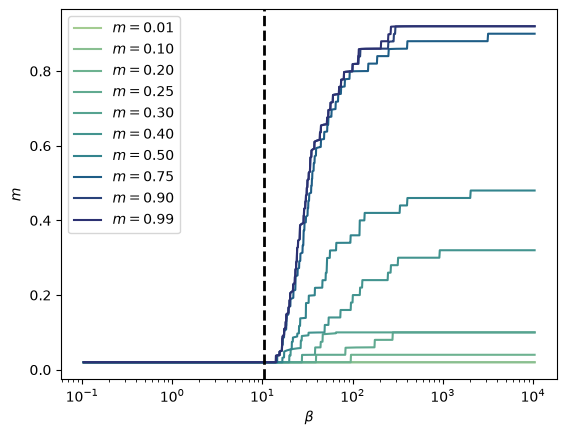

In [ ]:
if "masses" in experiment_name:
    for noise in database.keys():
        betas = database[noise]["betas"]
        final_magnetization = database[noise]["all_weights"][:, np.arange(K), np.arange(K)].mean(dim=-1)
        plt.plot(betas, final_magnetization, color=noise_colors[noise], label=f"$m={noise:.2f}$")
    plt.axvline(beta_c, color='black', linestyle='--', linewidth=2.0)
    plt.legend()
    plt.xlabel("$\\beta$")
    plt.ylabel("$m$")
    plt.xscale('log')
    plt.savefig(plots_path /  (save_file_structure + f"_final_magnetization.pdf"), bbox_inches='tight', dpi=300)
    plt.show()

### Entropy

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))
beta_c = None
for noise in database.keys():
    beta_c = database[noise]["beta_c"]
    K = database[noise]["patterns"].shape[0]
    mean_entropy = database[noise]["mean_entropy"]
    betas = database[noise]["betas"]
    ax.plot(betas, mean_entropy/log(K), color=noise_colors[noise], label=f"$\\sigma={noise:.2f}$")
if beta_c is not None:
    ax.axvline(beta_c, color='k', linestyle='--', label=f"$\\beta_c={beta_c:.2f}$", linewidth=2.0)
plt.xscale('log')
ax.set_xlabel("$\\beta$")
ax.set_ylabel("$H/\\log(K)$")
plt.legend()
plt.savefig(plots_path / f"{save_file_structure}_multi_entropy.pdf", dpi=300, bbox_inches='tight')
plt.show()

### Branching plots

In [ ]:
fig, axs = plt.subplots(ncols=len(database.keys()), figsize=(4*len(database.keys()), 4), sharex=True, sharey=True)
for plot_idx, noise in enumerate(database.keys()):
    dag = database[noise]["dag"]
    branching_nodes = database[noise]["branching_nodes"]
    x_fps = database[noise]["x_fps"]
    betas = database[noise]["betas"]
    patterns = database[noise]["patterns"]
    pca_model = PCA(n_components=2).fit(patterns)
    patterns_2d = pca_model.transform(patterns)
    axs[plot_idx].scatter(patterns_2d[:, 0], patterns_2d[:, 1], color='black', label=f"$\\sigma={noise:.2f}$", alpha=0.5, s=100)
    axs[plot_idx].set_title(f"$\\sigma={noise:.2f}$")
    axs[plot_idx].set_xlabel("PCA 1")
    axs[plot_idx].set_ylabel("PCA 2")
    beta_branching = [betas[node[0]].item() for node in branching_nodes]
    if len(beta_branching) <= 1:
        continue
    beta_min = min(beta_branching[:-1]) if len(beta_branching) > 1 else 0.0
    beta_max = max(beta_branching[:-1]) if len(beta_branching) > 1 else 0.0
    beta_c = database[noise]["beta_c"]
    for node_from in branching_nodes:
        color = cm.viridis((betas[node_from[0]].item() - beta_min) / (beta_max - beta_min)) if beta_max > beta_min else 'k'
        x_from  = x_fps[node_from[0]][node_from[1]]
        x_from_2d = pca_model.transform(x_from[None, :])[0]
        nodes_to = list(nx.neighbors(dag, node_from))
        axs[plot_idx].scatter(x_from_2d[0], x_from_2d[1], color=color, s=50, edgecolor='black')
        for node_to in nodes_to:
            x_to = x_fps[node_to[0]][node_to[1]]
            x_to_2d = pca_model.transform(x_to[None, :])[0]
            axs[plot_idx].quiver(
                x_from_2d[0], x_from_2d[1],
                x_to_2d[0]-x_from_2d[0], x_to_2d[1]-x_from_2d[1],
                angles='xy', scale_units='xy', scale=1, color=color, linewidth=3
            )
    colorbar = plt.cm.ScalarMappable(cmap=cm.viridis, norm=mcolors.Normalize(vmin=beta_min/beta_c, vmax=beta_max/beta_c))
    axins = axs[plot_idx].inset_axes([-0.05, -0.3, 1.0, 0.04])
    cbar = plt.colorbar(colorbar, cax=axins, orientation='horizontal', label="$\\beta/\\beta_c$")
plt.savefig(plots_path / f"{save_file_structure}_multi_branching_dag.pdf", dpi=300, bbox_inches='tight')
plt.show()

### Polygon plots

In [ ]:
for noise in database.keys():
    jump_indices = database[noise]["jump_indices"]
    betas = database[noise]["betas"]
    w_fps = database[noise]["w_fps"]
    all_weights = database[noise]["all_weights"]
    all_pol_repr = simplex_to_polygon(all_weights)
    pol_vertices = simplex_to_polygon(torch.eye(K))
    plt.scatter(pol_vertices[:,0], pol_vertices[:,1], color='black', s= 100, label="Patterns")
    for ic_idx in range(all_pol_repr.shape[1]):
        colored_line(all_pol_repr[jump_indices,ic_idx, 0],all_pol_repr[jump_indices,ic_idx, 1], c=betas[jump_indices].log(), ax=plt.gca(), cmap='coolwarm')
    plt.show()

# Variational Approximation

In [ ]:
is_centered = False
is_euclidean = True
raw_patterns = torch.clone(data.view(data.shape[0],-1)) if latents is None else torch.clone(latents.view(latents.shape[0],-1))
if is_centered or is_euclidean:
    shift, rms, patterns = mhn_utils.shift_and_rms(raw_patterns)
else:
    shift = torch.zeros(raw_patterns.shape[-1])
    rms = raw_patterns.norm(dim=1).square().mean().sqrt()
    rms = rms.clamp_min(1e-12)
    patterns = raw_patterns / rms
K = patterns.shape[0]
gram = patterns @ patterns.T
if is_euclidean:
    biases = -0.5*torch.diagonal(gram)
else:
    biases = torch.zeros(K)

In [ ]:
import numpy as np
import torch
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl

from itertools import combinations
from typing import List
from tqdm import tqdm


# ================================================================
# 1. Solve sparsemax stationary equations for many kappas at once
# ================================================================

def solve_dual_sparsemax(gram, biases, kappas, active_set, tol=1e-10):
    active_set = active_set.to(device=gram.device, dtype=torch.long)
    kappas = torch.as_tensor(kappas, device=gram.device, dtype=gram.dtype).reshape(-1)

    if active_set.numel() == 0:
        raise ValueError("active_set cannot be empty.")

    G = gram[active_set][:, active_set]
    a = biases[active_set]

    B, K, m = kappas.numel(), biases.numel(), active_set.numel()

    eye = torch.eye(m, device=gram.device, dtype=gram.dtype)
    ones = torch.ones(m, device=gram.device, dtype=gram.dtype)

    # [(kappa I - G)   1] [w     ] = [a]
    # [      1^T       0] [lambda]   [1]

    matrix = torch.zeros((B, m + 1, m + 1), device=gram.device, dtype=gram.dtype)
    matrix[:, :m, :m] = kappas[:, None, None] * eye[None, :, :] - G[None, :, :]
    matrix[:, :m, -1] = ones
    matrix[:, -1, :m] = ones

    rhs = torch.cat((a, torch.ones(1, device=gram.device, dtype=gram.dtype)))
    rhs = rhs[None, :].expand(B, -1)

    solution = torch.linalg.solve(matrix, rhs[..., None]).squeeze(-1)

    weights_active = solution[:, :-1]
    lagrange = solution[:, -1]

    weights = torch.zeros((B, K), device=gram.device, dtype=gram.dtype)
    weights[:, active_set] = weights_active

    # For inactive j:
    #
    #   (G w + a)_j <= lambda
    #
    # is the full-simplex KKT condition.
    logits = weights @ gram.T + biases[None, :]

    inactive_mask = torch.ones(K, dtype=torch.bool, device=gram.device)
    inactive_mask[active_set] = False
    inactive_indices = torch.where(inactive_mask)[0]

    # Validity on the selected face.
    active_valid = torch.all(weights_active > tol, dim=1)

    # Global K-dimensional event masks.
    expelled_mask = torch.zeros((B, K), dtype=torch.bool, device=gram.device)
    expelled_mask[:, active_set] = weights_active <= tol

    incoming_mask = torch.zeros((B, K), dtype=torch.bool, device=gram.device)

    if inactive_indices.numel() > 0:
        incoming_local_mask = logits[:, inactive_indices] > lagrange[:, None] + tol
        incoming_mask[:, inactive_indices] = incoming_local_mask
        inactive_valid = ~torch.any(incoming_local_mask, dim=1)
    else:
        inactive_valid = torch.ones(B, dtype=torch.bool, device=gram.device)

    return weights, lagrange, active_valid, inactive_valid, expelled_mask, incoming_mask


# ================================================================
# 2. Find first critical point while decreasing kappa
# ================================================================

def find_critical_point_sparsemax(
    gram,
    biases,
    kappa_min,
    kappa_max,
    active_set,
    num_kappas=1000,
    num_refinements=1,
    tol=1e-10,
    require_full_kkt=False,
):
    kappa_min = float(torch.as_tensor(kappa_min).item())
    kappa_max = float(torch.as_tensor(kappa_max).item())

    if kappa_max <= kappa_min:
        raise ValueError("kappa_max must be larger than kappa_min.")

    def scan(kappa_hi, kappa_lo):
        kappas = torch.linspace(
            kappa_hi,
            kappa_lo,
            steps=num_kappas,
            device=gram.device,
            dtype=gram.dtype,
        )

        weights, lagrange, active_valid, inactive_valid, expelled_mask, incoming_mask = solve_dual_sparsemax(
            gram,
            biases,
            kappas,
            active_set=active_set,
            tol=tol,
        )

        valid = active_valid & inactive_valid if require_full_kkt else active_valid

        return (
            kappas,
            weights,
            lagrange,
            active_valid,
            inactive_valid,
            expelled_mask,
            incoming_mask,
            valid,
        )

    # Initial scan from large kappa -> small kappa
    (
        kappas,
        weights,
        lagrange,
        active_valid,
        inactive_valid,
        expelled_mask,
        incoming_mask,
        valid,
    ) = scan(kappa_max, kappa_min)

    if not bool(valid[0].item()):
        raise ValueError("Active set is not valid at kappa_max.")

    unstable_indices = torch.where(~valid)[0]

    # No transition in the requested interval
    if unstable_indices.numel() == 0:
        idx = kappas.numel() - 1

        return {
            "transition_found": False,
            "stable_weights": weights[idx],
            "stable_lagrange": lagrange[idx],
            "stable_kappa": kappas[idx],
            "kappa_critical": None,
            "unstable_kappa": None,
            "first_unstable_weights": None,
            "first_unstable_lagrange": None,
            "first_unstable_expelled_mask": None,
            "first_unstable_incoming_mask": None,
            "stable_active_valid": bool(active_valid[idx].item()),
            "stable_inactive_valid": bool(inactive_valid[idx].item()),
        }

    first_unstable_idx = unstable_indices[0].item()

    if first_unstable_idx == 0:
        raise RuntimeError("No stable point exists above the first instability.")

    first_stable_idx = first_unstable_idx - 1

    stable_kappa = kappas[first_stable_idx]
    unstable_kappa = kappas[first_unstable_idx]

    stable_weights = weights[first_stable_idx]
    stable_lagrange = lagrange[first_stable_idx]

    unstable_weights = weights[first_unstable_idx]
    unstable_lagrange = lagrange[first_unstable_idx]

    unstable_expelled_mask = expelled_mask[first_unstable_idx]
    unstable_incoming_mask = incoming_mask[first_unstable_idx]

    stable_active_valid = active_valid[first_stable_idx]
    stable_inactive_valid = inactive_valid[first_stable_idx]

    # Refine the bracket
    for _ in range(num_refinements):
        (
            kappas,
            weights,
            lagrange,
            active_valid,
            inactive_valid,
            expelled_mask,
            incoming_mask,
            valid,
        ) = scan(float(stable_kappa), float(unstable_kappa))

        unstable_indices = torch.where(~valid)[0]

        if unstable_indices.numel() == 0:
            raise RuntimeError("Critical-point bracket was lost during refinement.")

        first_unstable_idx = unstable_indices[0].item()

        if first_unstable_idx == 0:
            raise RuntimeError("Refined bracket contains no stable upper point.")

        first_stable_idx = first_unstable_idx - 1

        stable_kappa = kappas[first_stable_idx]
        unstable_kappa = kappas[first_unstable_idx]

        stable_weights = weights[first_stable_idx]
        stable_lagrange = lagrange[first_stable_idx]

        unstable_weights = weights[first_unstable_idx]
        unstable_lagrange = lagrange[first_unstable_idx]

        unstable_expelled_mask = expelled_mask[first_unstable_idx]
        unstable_incoming_mask = incoming_mask[first_unstable_idx]

        stable_active_valid = active_valid[first_stable_idx]
        stable_inactive_valid = inactive_valid[first_stable_idx]

    kappa_critical = 0.5 * (stable_kappa + unstable_kappa)

    return {
        "transition_found": True,
        "stable_weights": stable_weights,
        "stable_lagrange": stable_lagrange,
        "stable_kappa": stable_kappa,
        "kappa_critical": kappa_critical,
        "unstable_kappa": unstable_kappa,
        "first_unstable_weights": unstable_weights,
        "first_unstable_lagrange": unstable_lagrange,
        "first_unstable_expelled_mask": unstable_expelled_mask,
        "first_unstable_incoming_mask": unstable_incoming_mask,
        "stable_active_valid": bool(stable_active_valid.item()),
        "stable_inactive_valid": bool(stable_inactive_valid.item()),
    }
# ================================================================
# 3. Candidate supports
# ================================================================

def generate_active_set_candidates(
    active_set: List[int],
    remaining_indices: List[int],
    expelled_indices: List[int],
    incoming_indices: List[int],
    include_complementary: bool = False,
) -> List[List[int]]:

    active_set = set(active_set)
    remaining_indices = set(remaining_indices)
    event_indices = sorted(set(expelled_indices) | set(incoming_indices))

    candidates = set()

    # Surviving branch:
    #
    #   R union S,  S subset E union I
    #
    for n in range(len(event_indices) + 1):
        for subset in combinations(event_indices, n):
            candidate = tuple(sorted(remaining_indices | set(subset)))

            if candidate and set(candidate) != active_set:
                candidates.add(candidate)

    # Optional detached/complementary branches:
    #
    #   S subset E union I
    #
    if include_complementary:
        for n in range(1, len(event_indices) + 1):
            for subset in combinations(event_indices, n):
                candidate = tuple(sorted(subset))

                if candidate and set(candidate) != active_set:
                    candidates.add(candidate)

    return [list(candidate) for candidate in sorted(candidates, key=lambda x: (len(x), x))]


# ================================================================
# 4. Helpers for the bifurcation DAG
# ================================================================

def _support_key(active_set):
    if torch.is_tensor(active_set):
        active_set = active_set.tolist()

    return tuple(sorted(int(i) for i in active_set))


def _intervals_overlap(lower_a, upper_a, lower_b, upper_b, rtol=1e-5, atol=1e-8):
    scale = max(abs(lower_a), abs(upper_a), abs(lower_b), abs(upper_b), 1.0)
    eps = atol + rtol * scale

    return max(lower_a, lower_b) <= min(upper_a, upper_b) + eps


def _find_matching_branch(
    bif_graph,
    branch_registry,
    support,
    kappa_lower,
    kappa_upper,
    parent_node,
    rtol=1e-5,
    atol=1e-8,
):
    key = _support_key(support)

    for existing_node in branch_registry.get(key, []):
        data = bif_graph.nodes[existing_node]

        if not _intervals_overlap(
            kappa_lower,
            kappa_upper,
            data["kappa_lower"],
            data["kappa_upper"],
            rtol=rtol,
            atol=atol,
        ):
            continue

        # Do not merge in a way that closes a directed cycle.
        if existing_node == parent_node:
            continue

        if nx.has_path(bif_graph, existing_node, parent_node):
            continue

        return existing_node

    return None


def _event_data(active_set, results, device):
    if results["transition_found"]:
        expelled_indices = torch.where(results["first_unstable_expelled_mask"])[0]
        incoming_indices = torch.where(results["first_unstable_incoming_mask"])[0]
        remaining_indices = active_set[~results["first_unstable_expelled_mask"][active_set]]

    else:
        expelled_indices = torch.empty(0, dtype=torch.long, device=device)
        incoming_indices = torch.empty(0, dtype=torch.long, device=device)
        remaining_indices = active_set

    return remaining_indices, expelled_indices, incoming_indices


# ================================================================
# 5. Construct bifurcation DAG
# ================================================================

def build_sparsemax_bifurcation_graph(
    gram,
    biases,
    kappa_min,
    kappa_max,
    max_bifurcations=None,
    include_complementary=False,
    num_kappas=1000,
    num_refinements=1,
    tol=1e-10,
    merge_rtol=1e-5,
    merge_atol=1e-8,
):
    K = biases.numel()

    if max_bifurcations is None:
        max_bifurcations = K

    kappa_min = float(kappa_min)
    kappa_max = float(kappa_max)

    # ------------------------------------------------------------
    # Root
    # ------------------------------------------------------------

    root_active_set = torch.arange(K, device=gram.device)

    root_results = find_critical_point_sparsemax(
        gram, biases,
        kappa_min=kappa_min,
        kappa_max=kappa_max,
        active_set=root_active_set,
        num_kappas=num_kappas,
        num_refinements=num_refinements,
        tol=tol,
        require_full_kkt=False,
    )

    root_remaining, root_expelled, root_incoming = _event_data(
        root_active_set, root_results, gram.device
    )

    root_lower = (
        float(root_results["kappa_critical"])
        if root_results["transition_found"]
        else kappa_min
    )

    bif_graph = nx.DiGraph()

    bif_graph.add_node(
        0,
        active_set=root_active_set,
        weights=root_results["stable_weights"],
        lagrange=root_results["stable_lagrange"],
        kappa=root_results["stable_kappa"],
        kappa_c=root_results["kappa_critical"],
        unstable_kappa=root_results["unstable_kappa"],

        kappa_lower=root_lower,
        kappa_upper=kappa_max,
        origin_kappas=[kappa_max],

        remaining_indices=root_remaining,
        expelled_indices=root_expelled,
        incoming_indices=root_incoming,

        full_kkt_valid=root_results["stable_inactive_valid"],
        transition_found=root_results["transition_found"],
        expanded=False,
    )

    branch_registry = {_support_key(root_active_set): [0]}
    node_counter = 1

    # ------------------------------------------------------------
    # Continue branches
    # ------------------------------------------------------------

    for _ in range(max_bifurcations):
        frontier = [node for node in bif_graph.nodes if not bif_graph.nodes[node]["expanded"]]

        if len(frontier) == 0:
            break

        for node in tqdm(frontier):
            node_data = bif_graph.nodes[node]

            if not node_data["transition_found"]:
                bif_graph.nodes[node]["expanded"] = True
                continue

            active_set = node_data["active_set"]
            remaining_indices = node_data["remaining_indices"]
            expelled_indices = node_data["expelled_indices"]
            incoming_indices = node_data["incoming_indices"]

            parent_kappa_c = float(node_data["kappa_c"])
            parent_unstable_kappa = float(node_data["unstable_kappa"])

            candidates = generate_active_set_candidates(
                active_set.tolist(),
                remaining_indices.tolist(),
                expelled_indices.tolist(),
                incoming_indices.tolist(),
                include_complementary=include_complementary,
            )

            for candidate in candidates:
                candidate_set = torch.as_tensor(candidate, dtype=torch.long, device=gram.device)

                # ----------------------------------------------------
                # Cheap test immediately below parent transition.
                # ----------------------------------------------------

                test_kappa = torch.as_tensor(
                    [parent_unstable_kappa],
                    device=gram.device,
                    dtype=gram.dtype,
                )

                try:
                    test_weights, test_lagrange, active_valid, inactive_valid, _, _ = solve_dual_sparsemax(
                        gram, biases, test_kappa, candidate_set, tol=tol
                    )

                except RuntimeError:
                    continue

                if not bool(active_valid[0].item()):
                    continue

                # ----------------------------------------------------
                # Continue candidate downward.
                # ----------------------------------------------------

                if parent_unstable_kappa <= kappa_min:
                    results = {
                        "transition_found": False,

                        "stable_weights": test_weights[0],
                        "stable_lagrange": test_lagrange[0],
                        "stable_kappa": test_kappa[0],

                        "kappa_critical": None,
                        "unstable_kappa": None,

                        "first_unstable_weights": None,
                        "first_unstable_lagrange": None,
                        "first_unstable_expelled_mask": None,
                        "first_unstable_incoming_mask": None,

                        "stable_active_valid": True,
                        "stable_inactive_valid": bool(inactive_valid[0].item()),
                    }

                else:
                    try:
                        results = find_critical_point_sparsemax(
                            gram, biases,
                            kappa_min=kappa_min,
                            kappa_max=parent_unstable_kappa,
                            active_set=candidate_set,
                            num_kappas=num_kappas,
                            num_refinements=num_refinements,
                            tol=tol,
                            require_full_kkt=False,
                        )

                    except (RuntimeError, ValueError):
                        continue

                child_remaining, child_expelled, child_incoming = _event_data(
                    candidate_set, results, gram.device
                )

                child_lower = (
                    float(results["kappa_critical"])
                    if results["transition_found"]
                    else kappa_min
                )

                child_upper = parent_kappa_c

                # ----------------------------------------------------
                # Merge if this is the same support branch over an
                # overlapping kappa interval.
                # ----------------------------------------------------

                existing_node = _find_matching_branch(
                    bif_graph,
                    branch_registry,
                    candidate,
                    child_lower,
                    child_upper,
                    parent_node=node,
                    rtol=merge_rtol,
                    atol=merge_atol,
                )

                if existing_node is not None:
                    bif_graph.add_edge(node, existing_node)

                    existing_data = bif_graph.nodes[existing_node]
                    existing_data["kappa_lower"] = min(existing_data["kappa_lower"], child_lower)
                    existing_data["kappa_upper"] = max(existing_data["kappa_upper"], child_upper)
                    existing_data["origin_kappas"].append(parent_kappa_c)

                    continue

                # ----------------------------------------------------
                # New branch node.
                # ----------------------------------------------------

                bif_graph.add_node(
                    node_counter,
                    active_set=candidate_set,
                    weights=results["stable_weights"],
                    lagrange=results["stable_lagrange"],
                    kappa=results["stable_kappa"],
                    kappa_c=results["kappa_critical"],
                    unstable_kappa=results["unstable_kappa"],

                    kappa_lower=child_lower,
                    kappa_upper=child_upper,
                    origin_kappas=[parent_kappa_c],

                    remaining_indices=child_remaining,
                    expelled_indices=child_expelled,
                    incoming_indices=child_incoming,

                    full_kkt_valid=results["stable_inactive_valid"],
                    transition_found=results["transition_found"],
                    expanded=False,
                )

                bif_graph.add_edge(node, node_counter)

                key = _support_key(candidate)

                if key not in branch_registry:
                    branch_registry[key] = []

                branch_registry[key].append(node_counter)

                node_counter += 1

            bif_graph.nodes[node]["expanded"] = True

    if not nx.is_directed_acyclic_graph(bif_graph):
        raise RuntimeError("Internal error: bifurcation graph contains a directed cycle.")

    return bif_graph


# ================================================================
# 6. Plot bifurcation DAG
# ================================================================

def plot_bifurcation_graph(
    bif_graph,
    K=None,
    figsize=None,
    node_size=900,
    font_size=9,
    beta_font_size=11,
    show_remaining=True,
    show_active=False,
    show_kkt=True,
    vertical="rank",
):
    if len(bif_graph) == 0:
        raise ValueError("bif_graph is empty.")

    if not nx.is_directed_acyclic_graph(bif_graph):
        raise ValueError("bif_graph contains a directed cycle.")

    # ------------------------------------------------------------
    # Determine K
    # ------------------------------------------------------------

    if K is None:
        all_indices = []

        for _, data in bif_graph.nodes(data=True):
            active_set = data.get("active_set", [])
            active_set = active_set.tolist() if torch.is_tensor(active_set) else list(active_set)
            all_indices.extend(active_set)

        K = max(all_indices) + 1 if all_indices else 1

    # ------------------------------------------------------------
    # Hierarchical layout
    # ------------------------------------------------------------

    try:
        pos = nx.nx_agraph.graphviz_layout(
            bif_graph,
            prog="dot",
            args="-Grankdir=TB -Granksep=1.4 -Gnodesep=0.7",
        )

    except Exception:
        try:
            pos = nx.nx_pydot.graphviz_layout(bif_graph, prog="dot")

        except Exception:
            generations = list(nx.topological_generations(bif_graph))
            pos = {}

            max_width = max(len(generation) for generation in generations)

            for level, generation in enumerate(generations):
                generation = list(generation)

                if level > 0:
                    generation.sort(
                        key=lambda node: np.mean(
                            [pos[parent][0] for parent in bif_graph.predecessors(node)]
                        ) if bif_graph.in_degree(node) > 0 else 0.0
                    )

                width = len(generation)
                xs = [0.0] if width == 1 else np.linspace(
                    -(max_width - 1) / 2,
                    +(max_width - 1) / 2,
                    width,
                )

                for x, node in zip(xs, generation):
                    pos[node] = (x, -level)

    pos = {node: (float(x), float(y)) for node, (x, y) in pos.items()}

    # ------------------------------------------------------------
    # Optional physical y-axis = beta_c
    # ------------------------------------------------------------

    if vertical == "beta":
        beta_values = {}

        for node, data in bif_graph.nodes(data=True):
            kappa_c = data.get("kappa_c")

            if kappa_c is not None:
                beta_values[node] = 2.0 * np.log(2.0) / float(kappa_c)

        if beta_values:
            beta_min = min(beta_values.values())
            beta_max = max(beta_values.values())
            beta_step = max(0.08 * max(beta_max - beta_min, 1.0), 0.05)

            for node in bif_graph.nodes:
                if node in beta_values:
                    pos[node] = (pos[node][0], beta_values[node])

                else:
                    parents = list(bif_graph.predecessors(node))

                    if parents:
                        pos[node] = (pos[node][0], max(pos[parent][1] for parent in parents) + beta_step)
                    else:
                        pos[node] = (pos[node][0], beta_min)

    elif vertical != "rank":
        raise ValueError("vertical must be 'rank' or 'beta'.")

    # ------------------------------------------------------------
    # Figure size
    # ------------------------------------------------------------

    if figsize is None:
        generations = list(nx.topological_generations(bif_graph))
        max_width = max(len(g) for g in generations)
        depth = len(generations)

        figsize = (
            min(40, max(12, 1.5 * max_width)),
            min(35, max(8, 1.8 * depth)),
        )

    fig, ax = plt.subplots(figsize=figsize)

    nodes = list(bif_graph.nodes)

    # ------------------------------------------------------------
    # Node colors = active support size
    # ------------------------------------------------------------

    active_sizes = [len(bif_graph.nodes[node]["active_set"]) for node in nodes]

    norm = mpl.colors.Normalize(vmin=1, vmax=max(K, 2))
    cmap = plt.cm.viridis

    node_colors = [cmap(norm(size)) for size in active_sizes]

    if show_kkt:
        edge_colors = [
            "black" if bif_graph.nodes[node].get("full_kkt_valid", False) else "0.65"
            for node in nodes
        ]

        line_widths = [
            2.3 if bif_graph.nodes[node].get("full_kkt_valid", False) else 1.0
            for node in nodes
        ]

    else:
        edge_colors = "black"
        line_widths = 1.5

    # ------------------------------------------------------------
    # Edges
    # ------------------------------------------------------------

    nx.draw_networkx_edges(
        bif_graph,
        pos,
        ax=ax,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=22,
        width=1.5,
        edge_color="0.35",
        min_source_margin=18,
        min_target_margin=18,
        connectionstyle="arc3,rad=0.02",
    )

    # ------------------------------------------------------------
    # Nodes
    # ------------------------------------------------------------

    nx.draw_networkx_nodes(
        bif_graph,
        pos,
        ax=ax,
        nodelist=nodes,
        node_size=node_size,
        node_color=node_colors,
        edgecolors=edge_colors,
        linewidths=line_widths,
    )

    xs = np.asarray([pos[node][0] for node in nodes])
    ys = np.asarray([pos[node][1] for node in nodes])

    y_span = max(float(ys.max() - ys.min()), 1.0)

    beta_offset = 0.035 * y_span
    index_offset = 0.045 * y_span

    if vertical == "rank":
        beta_sign = +1
        index_sign = -1
    else:
        beta_sign = -1
        index_sign = +1

    # ------------------------------------------------------------
    # Labels
    # ------------------------------------------------------------

    for node in nodes:
        data = bif_graph.nodes[node]
        x, y = pos[node]

        kappa_c = data.get("kappa_c")
        transition_found = data.get("transition_found", True)

        if kappa_c is not None:
            beta_c = 2.0 * np.log(2.0) / float(kappa_c)
            beta_text = rf"$\beta_c={beta_c:.3g}$"
        elif not transition_found:
            beta_text = "terminal"
        else:
            beta_text = ""

        if beta_text:
            ax.text(
                x,
                y + beta_sign * beta_offset,
                beta_text,
                ha="center",
                va="center",
                fontsize=beta_font_size,
                fontweight="bold",
            )

        labels = []

        if show_active:
            active = data["active_set"]
            active = active.tolist() if torch.is_tensor(active) else list(active)
            labels.append("A={" + ",".join(map(str, active)) + "}")

        if show_remaining:
            remaining = data["remaining_indices"]
            remaining = remaining.tolist() if torch.is_tensor(remaining) else list(remaining)
            labels.append("R={" + ",".join(map(str, remaining)) + "}")

        if labels:
            ax.text(
                x,
                y + index_sign * index_offset,
                "\n".join(labels),
                ha="center",
                va="center",
                fontsize=font_size,
            )

    # ------------------------------------------------------------
    # Colorbar
    # ------------------------------------------------------------

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Number of active sites")

    # ------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------

    if vertical == "beta":
        ax.invert_yaxis()
        ax.set_ylabel(r"$\beta_c$")
    else:
        ax.set_yticks([])

    ax.set_xticks([])
    ax.set_title("Sparsemax bifurcation graph", fontsize=14)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.margins(x=0.08, y=0.10)
    fig.tight_layout()

    return fig, ax

In [ ]:
bif_graph = build_sparsemax_bifurcation_graph(
    gram,
    biases,
    kappa_min=0.1,
    kappa_max=10.0,
    include_complementary=True,
    num_kappas=1000,
    num_refinements=1,
)

In [ ]:
plot_bifurcation_graph(
    bif_graph,
    K=K,
    figsize=(16, 10),
    node_size=1100,
    font_size=9,
    beta_font_size=11,
    show_remaining=True,
    show_active=False,
    show_kkt=False,
    vertical="rank",
)